In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
print(df.columns.tolist())
print(df.shape)

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
(8807, 12)


In [3]:
##  Checking for missing values

print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [4]:
##  Checking the  data types

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [5]:
##  Checking basic statistics

print(df.describe())

       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [6]:
 ## Cleaning the data

In [7]:
##  Filling the missing values

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')
print('Missing values filled')

Missing values filled


In [8]:
##  Droping rows with missing date_added

df = df.dropna(subset=['date_added'])
print(df.shape)

(8797, 12)


In [9]:
##  Convert date_added to proper date format

df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
print(df['date_added'].head())

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]


In [10]:
## Extracting year and month from date_added

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
print(df[['date_added', 'year_added', 'month_added']].head())

  date_added  year_added  month_added
0 2021-09-25        2021            9
1 2021-09-24        2021            9
2 2021-09-24        2021            9
3 2021-09-24        2021            9
4 2021-09-24        2021            9


In [11]:
##  Confirming everything is clean

print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64


In [12]:
## Analyzing the data



In [13]:
##  Movies vs TV Shows

content_type = df['type'].value_counts()
print(content_type)

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


In [14]:
##  Top 10 countries producing most content

top_countries = df['country'].value_counts().head(10)
print(top_countries)

country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [15]:
##   Most common ratings

top_ratings = df['rating'].value_counts().head(10)
print(top_ratings)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64


In [16]:
##   Content added per year

yearly_content = df['year_added'].value_counts().sort_index()
print(yearly_content)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


In [17]:
##  Most popular genres

genres = df['listed_in'].str.split(',').explode().str.strip().value_counts().head(10)
print(genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [18]:
##  Movies vs TV Shows per year

yearly_type = df.groupby(['year_added', 'type']).size().unstack()
print(yearly_type)

type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      NaN
2010           1.0      NaN
2011          13.0      NaN
2012           3.0      NaN
2013           6.0      5.0
2014          19.0      5.0
2015          56.0     26.0
2016         253.0    176.0
2017         839.0    349.0
2018        1237.0    412.0
2019        1424.0    592.0
2020        1284.0    595.0
2021         993.0    505.0


In [19]:
## visualization


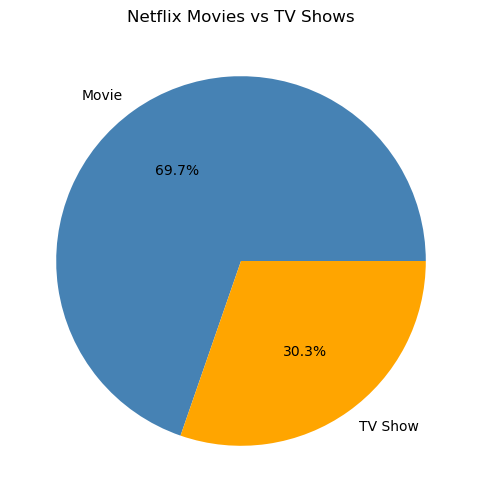

In [20]:
##  Movies vs TV Shows (Pie Chart)

plt.figure(figsize=(8,6))
content_type.plot(kind='pie', autopct='%1.1f%%', colors=['steelblue', 'orange'])
plt.title('Netflix Movies vs TV Shows')
plt.ylabel('')
plt.show()

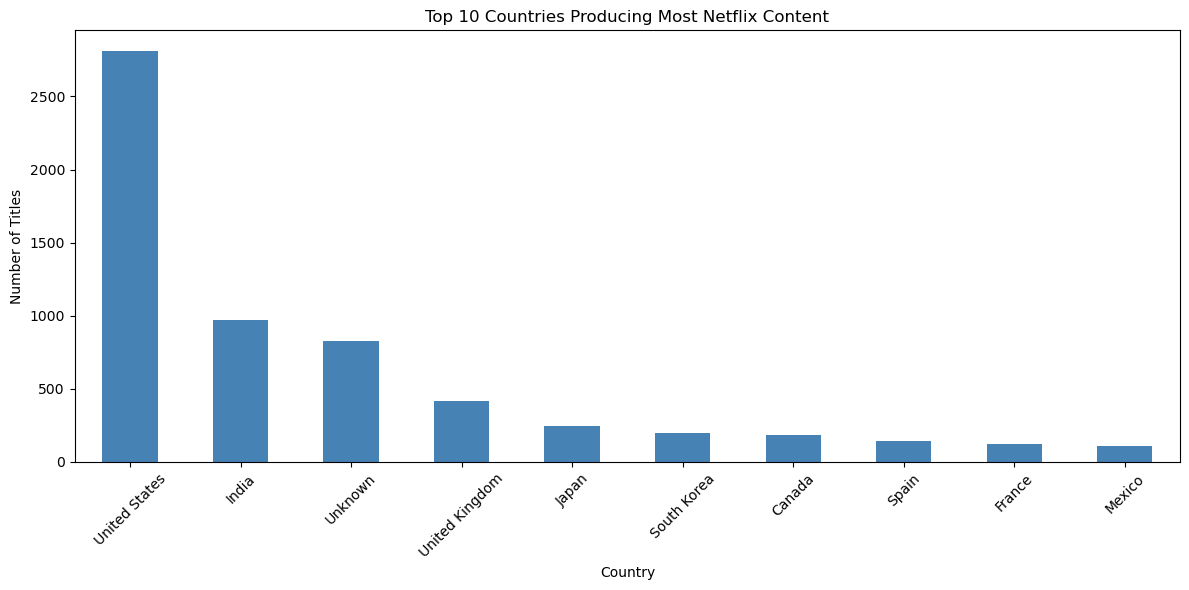

In [21]:
##  Top 10 Countries (Bar Chart)

plt.figure(figsize=(12,6))
top_countries.plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries Producing Most Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

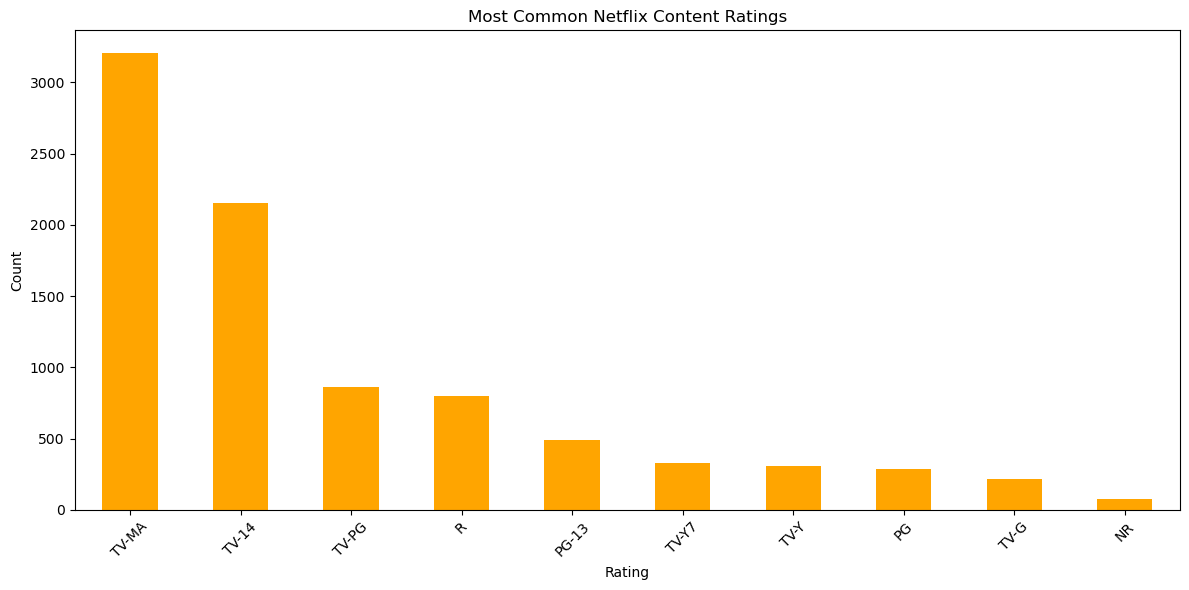

In [22]:
##  Most Common Ratings (Bar Chart)

plt.figure(figsize=(12,6))
top_ratings.plot(kind='bar', color='orange')
plt.title('Most Common Netflix Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

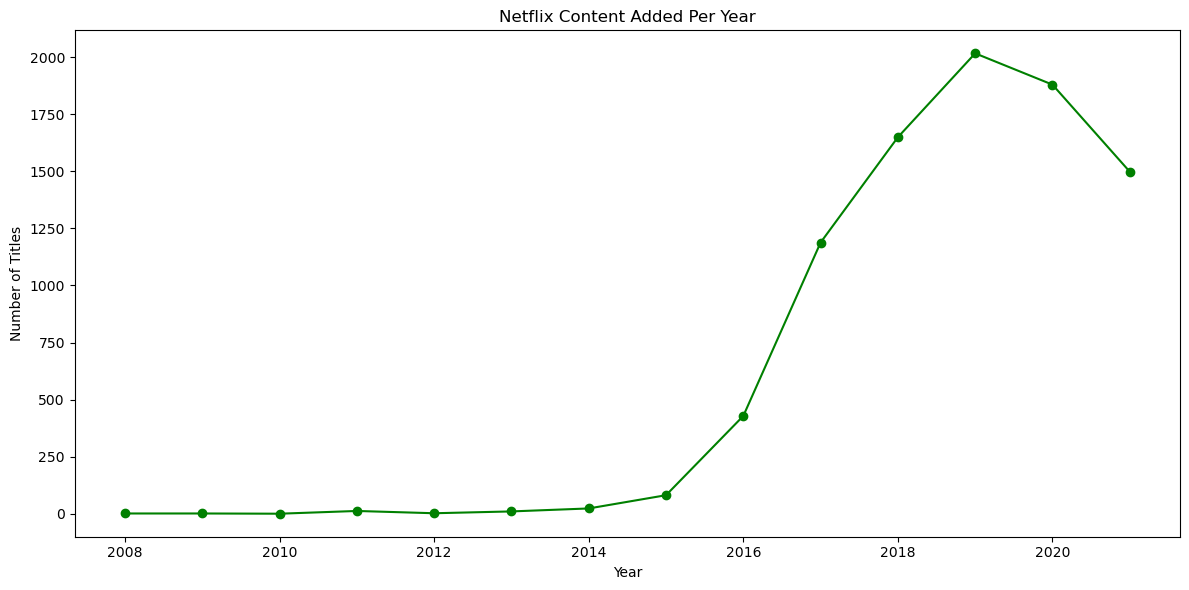

In [23]:
##  Content Added Per Year (Line Chart)

plt.figure(figsize=(12,6))
yearly_content.plot(kind='line', color='green', marker='o')
plt.title('Netflix Content Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

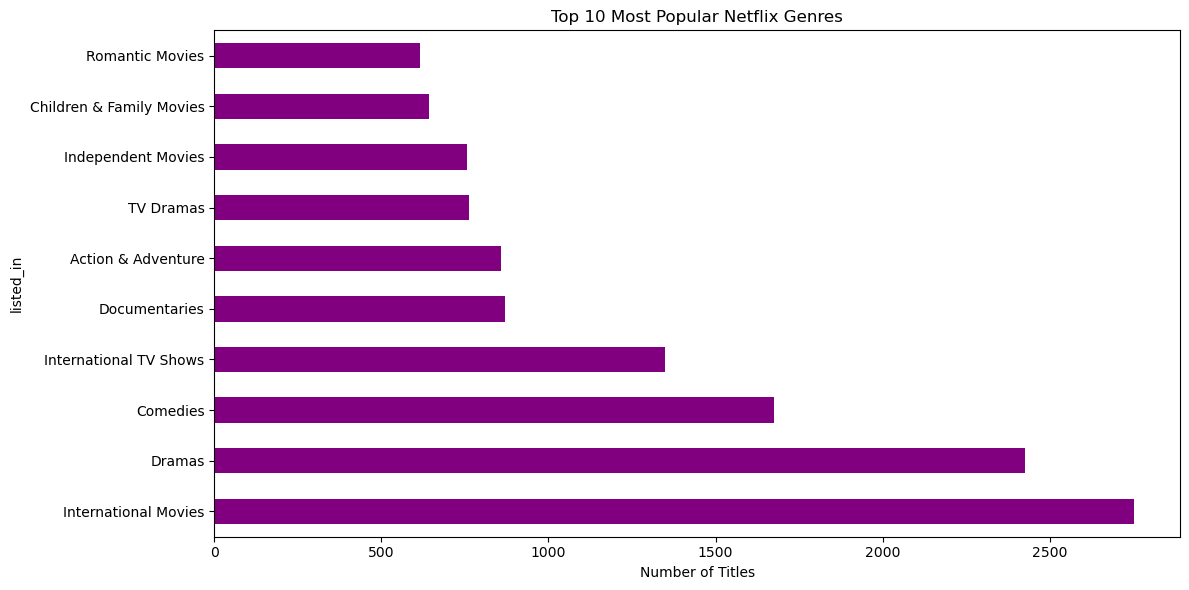

In [24]:
##  Top 10 Genres (Bar Chart)

plt.figure(figsize=(12,6))
genres.plot(kind='barh', color='purple')
plt.title('Top 10 Most Popular Netflix Genres')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

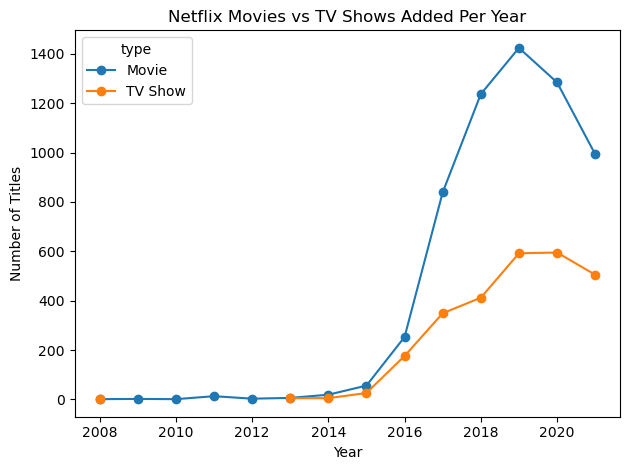

In [25]:
##  Movies vs TV Shows Growth Over Years (Line Chart)

plt.figure(figsize=(12,6))
yearly_type.plot(kind='line', marker='o')
plt.title('Netflix Movies vs TV Shows Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

In [26]:
df.to_csv('netflix_cleaned.csv', index=False)
print('File saved successfully')

File saved successfully


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df = df.dropna(subset=['date_added'])
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')
print('Data loaded successfully')
print(df.shape)

Data loaded successfully
(8797, 14)


In [28]:
##  Content Duration Analysis

# Movies duration
movies = df[df['type'] == 'Movie'].copy()
movies['minutes'] = movies['duration'].str.replace(' min', '').str.strip()
movies['minutes'] = pd.to_numeric(movies['minutes'], errors='coerce')
movies = movies.dropna(subset=['minutes'])

print("=== MOVIE DURATION ANALYSIS ===")
print(f"Average Movie Length: {movies['minutes'].mean():.0f} minutes")
print(f"Longest Movie: {movies['minutes'].max():.0f} minutes")
print(f"Shortest Movie: {movies['minutes'].min():.0f} minutes")

# TV Shows seasons
tvshows = df[df['type'] == 'TV Show'].copy()
tvshows['seasons'] = tvshows['duration'].str.replace(' Seasons', '').str.replace(' Season', '').str.strip()
tvshows['seasons'] = pd.to_numeric(tvshows['seasons'], errors='coerce')
tvshows = tvshows.dropna(subset=['seasons'])

print("\n=== TV SHOW SEASONS ANALYSIS ===")
print(f"Average Seasons: {tvshows['seasons'].mean():.1f} seasons")
print(f"Most Seasons: {tvshows['seasons'].max():.0f} seasons")

=== MOVIE DURATION ANALYSIS ===
Average Movie Length: 100 minutes
Longest Movie: 312 minutes
Shortest Movie: 3 minutes

=== TV SHOW SEASONS ANALYSIS ===
Average Seasons: 1.8 seasons
Most Seasons: 17 seasons


In [29]:
##Top 10 Most Prolific Directors

directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)
print("=== TOP 10 MOST PROLIFIC DIRECTORS ===")
print(directors)

=== TOP 10 MOST PROLIFIC DIRECTORS ===
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


In [30]:
##  Monthly Content Addition Trend

monthly = df.groupby('month_added').size()
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly.index = monthly.index.map(month_names)
print("=== MONTHLY CONTENT ADDITION ===")
print(monthly)

=== MONTHLY CONTENT ADDITION ===
month_added
Jan    738
Feb    563
Mar    742
Apr    764
May    632
Jun    728
Jul    827
Aug    755
Sep    770
Oct    760
Nov    705
Dec    813
dtype: int64


In [31]:
##  Release Year vs Year Added Gap

df['content_age_when_added'] = df['year_added'] - df['release_year']
print("=== CONTENT AGE WHEN ADDED TO NETFLIX ===")
print(f"Average Age of Content When Added: {df['content_age_when_added'].mean():.1f} years")
print(f"Oldest Content When Added: {df['content_age_when_added'].max():.0f} years")
print(f"Newest Content When Added: {df['content_age_when_added'].min():.0f} years")

=== CONTENT AGE WHEN ADDED TO NETFLIX ===
Average Age of Content When Added: 4.7 years
Oldest Content When Added: 93 years
Newest Content When Added: -3 years


In [32]:
##  Most Common Words in Descriptions

from collections import Counter
import re

all_words = ' '.join(df['description'].dropna()).lower()
words = re.findall(r'\b[a-z]{4,}\b', all_words)
stopwords = ['that', 'this', 'with', 'from', 'their', 'when', 'will', 'after',
             'life', 'must', 'find', 'they', 'them', 'have', 'each', 'into',
             'been', 'more', 'also', 'only', 'then', 'than', 'about', 'what']
words_filtered = [w for w in words if w not in stopwords]
word_counts = Counter(words_filtered).most_common(15)
print("=== MOST COMMON WORDS IN NETFLIX DESCRIPTIONS ===")
for word, count in word_counts:
    print(f"{word}: {count}")

=== MOST COMMON WORDS IN NETFLIX DESCRIPTIONS ===
young: 729
family: 635
world: 569
love: 503
woman: 486
friends: 445
series: 395
while: 376
documentary: 365
school: 339
father: 317
home: 317
finds: 313
where: 301
three: 300


In [33]:
##  second visualization

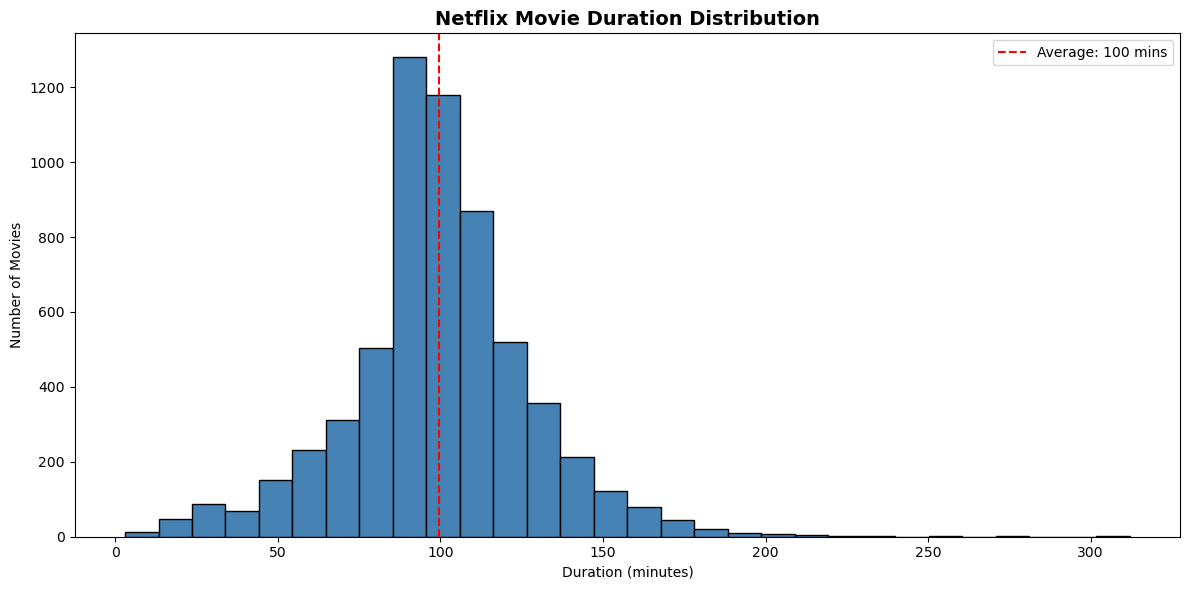

In [34]:
##  Movie Duration Distribution

plt.figure(figsize=(12,6))
plt.hist(movies['minutes'], bins=30, color='steelblue', edgecolor='black')
plt.axvline(x=movies['minutes'].mean(), color='red', linestyle='--', label=f'Average: {movies["minutes"].mean():.0f} mins')
plt.title('Netflix Movie Duration Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.legend()
plt.tight_layout()
plt.show()

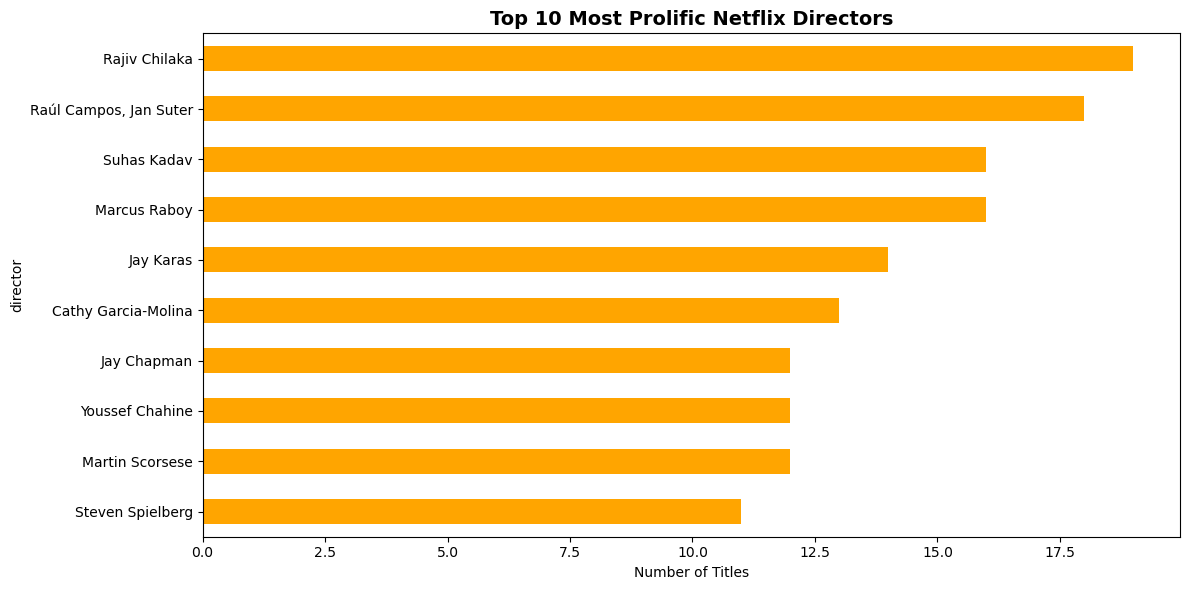

In [35]:
##  Top 10 Most Prolific Directors

plt.figure(figsize=(12,6))
directors.sort_values().plot(kind='barh', color='orange')
plt.title('Top 10 Most Prolific Netflix Directors', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.show()

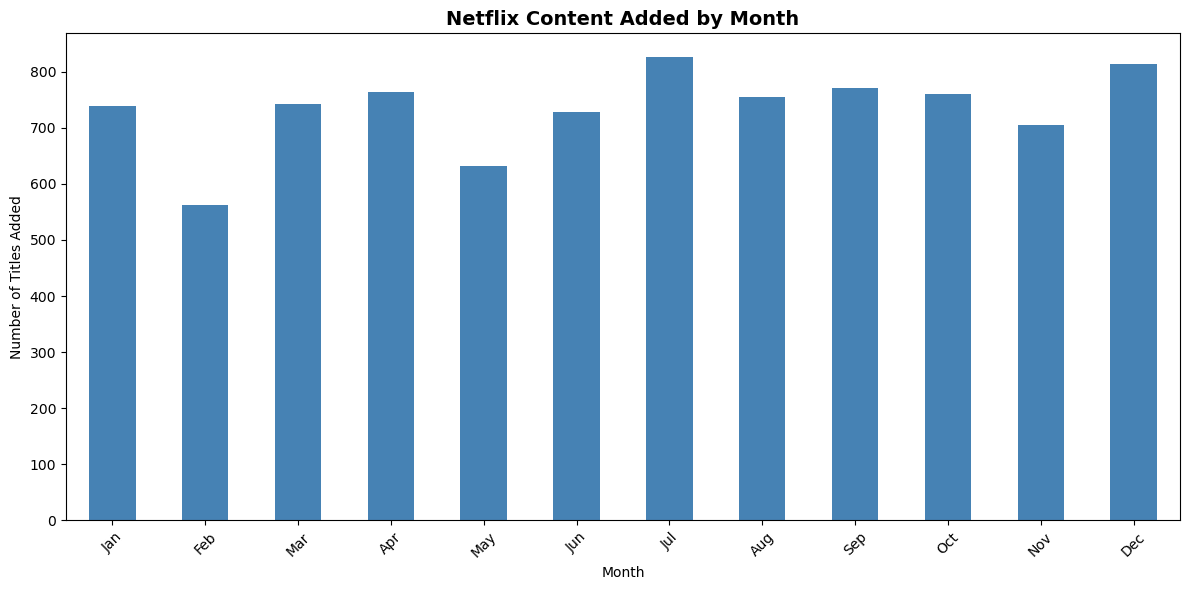

In [36]:
##  Monthly Content Addition

plt.figure(figsize=(12,6))
monthly.plot(kind='bar', color='steelblue')
plt.title('Netflix Content Added by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

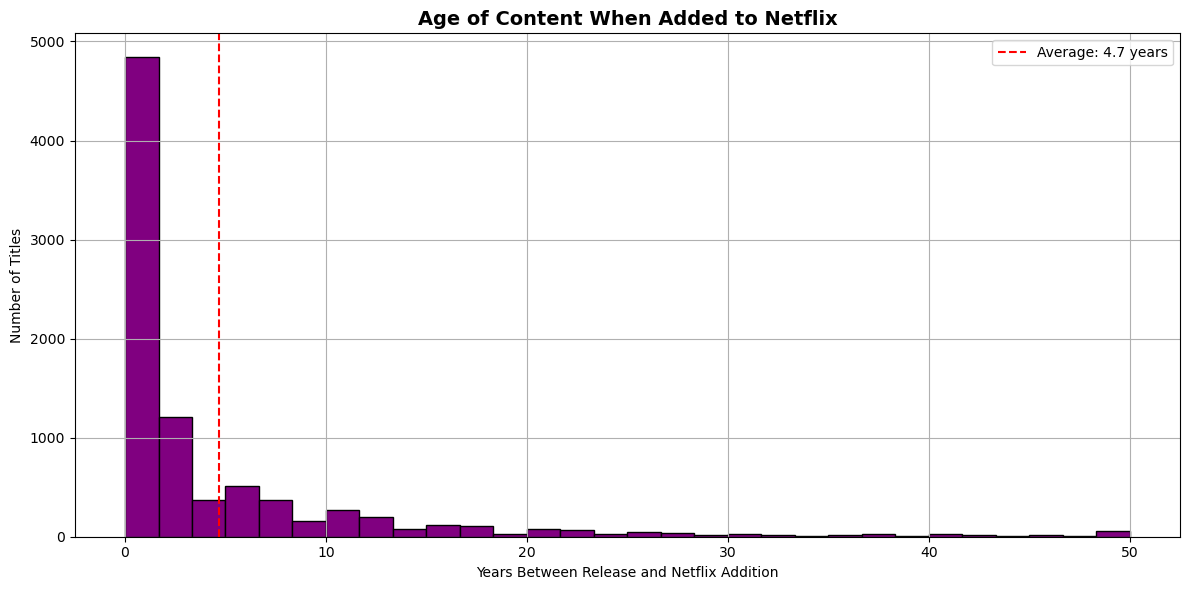

In [37]:
##  Content Age When Added

plt.figure(figsize=(12,6))
df['content_age_when_added'].clip(0, 50).hist(bins=30, color='purple', edgecolor='black')
plt.axvline(x=df['content_age_when_added'].mean(), color='red', linestyle='--', label=f'Average: {df["content_age_when_added"].mean():.1f} years')
plt.title('Age of Content When Added to Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Years Between Release and Netflix Addition')
plt.ylabel('Number of Titles')
plt.legend()
plt.tight_layout()
plt.show()

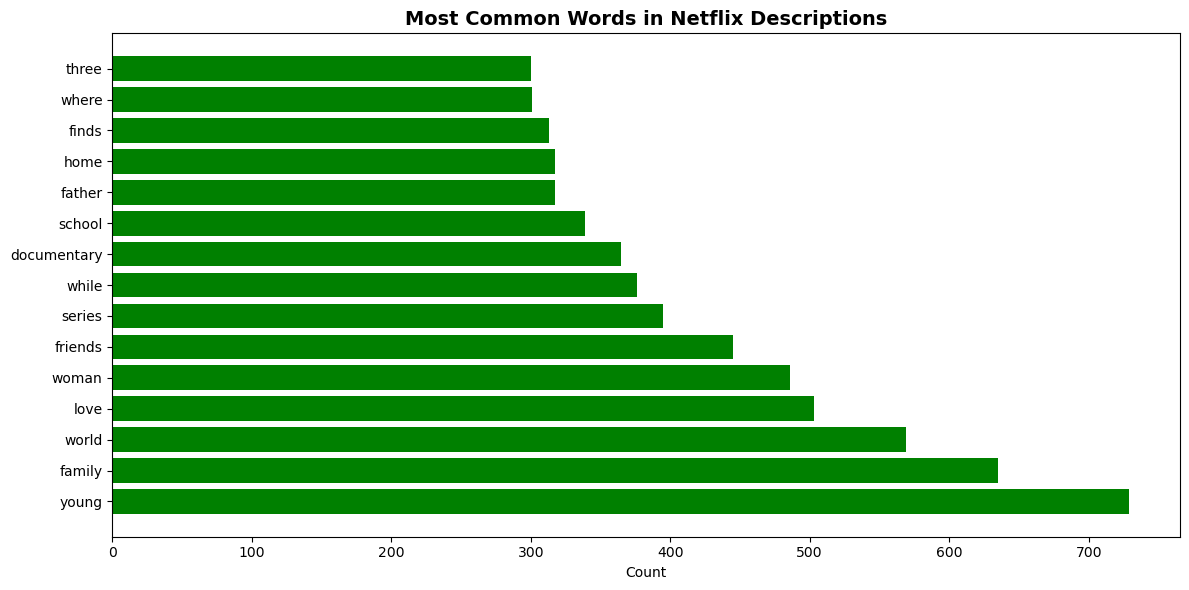

In [38]:
##   Most Common Words Bar Chart

words_df = pd.DataFrame(word_counts, columns=['Word', 'Count'])
plt.figure(figsize=(12,6))
plt.barh(words_df['Word'], words_df['Count'], color='green')
plt.title('Most Common Words in Netflix Descriptions', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

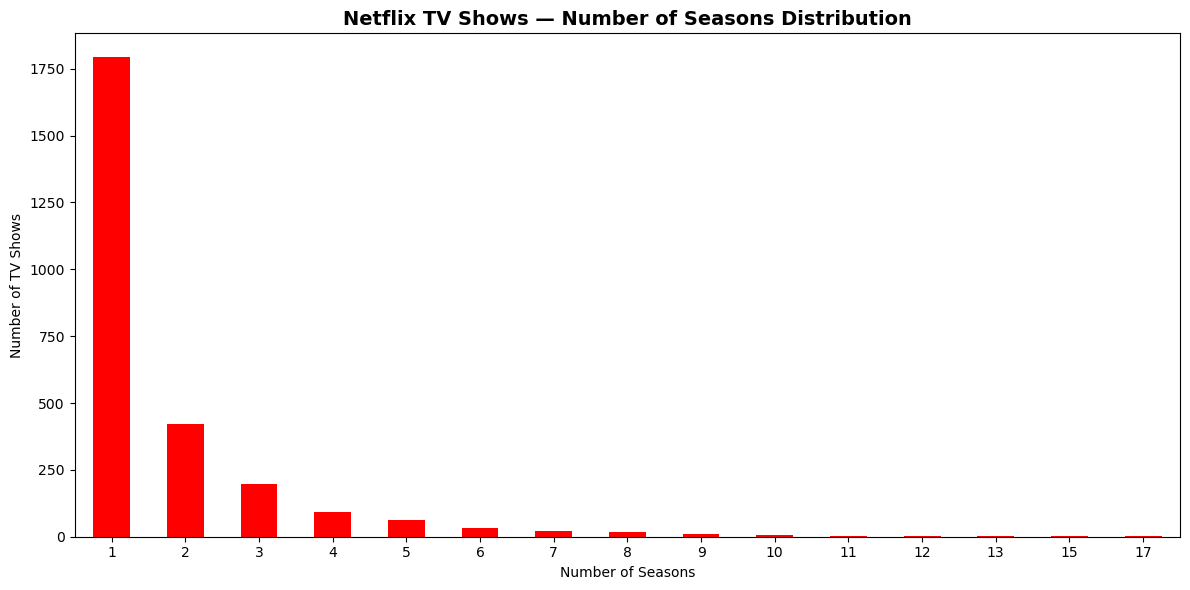

In [39]:
##  TV Shows Seasons Distribution

plt.figure(figsize=(12,6))
tvshows['seasons'].value_counts().sort_index().plot(kind='bar', color='red')
plt.title('Netflix TV Shows — Number of Seasons Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
df['minutes'] = pd.to_numeric(df['duration'].str.replace(' min', '').str.strip(), errors='coerce')
df.to_csv('netflix_cleaned.csv', index=False)
print('File saved successfully')

File saved successfully


In [43]:
df['minutes'] = pd.to_numeric(df['duration'].str.replace(' min', '').str.strip(), errors='coerce')
df.to_csv('netflix_cleaned.csv', index=False)
print('File saved with minutes column')
print(df['minutes'].head())

File saved with minutes column
0    90.0
1     NaN
2     NaN
3     NaN
4     NaN
Name: minutes, dtype: float64


In [44]:
# Reload fresh
df = pd.read_csv('netflix_titles.csv')
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df = df.dropna(subset=['date_added'])
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')
df['content_age_when_added'] = df['year_added'] - df['release_year']

# Remove minutes column completely
if 'minutes' in df.columns:
    df = df.drop(columns=['minutes'])

# Save
df.to_csv('netflix_cleaned.csv', index=False)
print('File saved successfully')
print(df.columns.tolist())

File saved successfully
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'year_added', 'month_added', 'content_age_when_added']
